In [4]:
%load_ext autoreload
%autoreload 2

import os
import sys

import pandas as pd
    
sys.path.insert(1, "../../")

import precision_mapping as pm
import CAP_tools


sys.path.insert(1, "../../network_control")
import surface_mapping as sfm

# HCP PM Pipeline 

### Parameters

In [5]:
overwrite = False

exclude_subcortex = True
mask = False
sparsity = 0.1
max_trs = 300

silent = True

pm.utils.printer.silent = silent

### paths

In [6]:
results_dir = "/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL"
dtseries_list_txt = "/data/data7/network_control/scripts/_params/HCP_7T_CAP_analysis/HCP_7T_CAP_analysis_rfMRI_REST_7T_ALL_dtseries_list.txt"

with open(dtseries_list_txt) as file:
    dtseries_paths = file.read().strip().split()

cached_dtseries_paths = pm.utils.cache_tmp_path(dtseries_paths, write_cache=False)

subjects = [path.split("/MNINon")[0].split("/")[-1] for path in dtseries_paths]

voxel_FC_file_ending = "voxel_FC.npz"
parcel_file_ending = "parcellation.npy"
network_file_ending = "networks.npy"

Caching paths in ~/_tmp:   0%|          | 0/177 [00:00<?, ?it/s]

In [7]:
import nibabel as nb
import numpy as np

from tqdm.auto import tqdm

def cifti_to_npy(cifti_path, npy_path, dtype="float16"):
    """ """
    data = nb.load(cifti_path).get_fdata(caching="unchanged", dtype=dtype)
    np.save(npy_path, data)

tmp_files = [z for z in cached_dtseries_paths if "_tmp" in z]

for cifti_path in tqdm(tmp_files):
    assert ".dtseries.nii" in cifti_path
    npy_path = cifti_path.replace(".dtseries.nii", ".npy")
    if os.path.exists(npy_path):
        continue
    cifti_to_npy(cifti_path, npy_path, dtype="float16")


npy_cached_dtseries_paths = [z.replace(".dtseries.nii", ".npy") if "_tmp" in z else z
                             for z in cached_dtseries_paths]

npy_subjects = [subject for dt_path, subject in zip(npy_cached_dtseries_paths, subjects) if dt_path.endswith(".npy")]
npy_cached_dtseries_paths = [dt_path for dt_path in npy_cached_dtseries_paths if dt_path.endswith(".npy")]

assert len(npy_subjects) == len(npy_cached_dtseries_paths)

  0%|          | 0/177 [00:00<?, ?it/s]

KeyboardInterrupt: 

##### Sparse dconn creation

In [8]:
import gc
import torch

# TODO: Correlations are fixed, now add other steps in pipelines

In [297]:
# for max_trs in [300, 600, 1200, 2400]:
for max_trs in [None, 300, 1200, 2400]:
# for max_trs in [300, 1200, 2400, None]:
# for max_trs in [None]:
    generic_save_paths = []
    for subject in subjects:
        label_tag = pm.utils.create_path_tag(subject, sparsity, mask, exclude_subcortex, max_trs=max_trs)
        generic_save_paths.append(f"{results_dir}/{subject}/{label_tag}_{{file_ending}}")
        # print()
        os.makedirs(f"{results_dir}/{subject}", exist_ok=True)

    voxel_FC_save_paths = [path.format(file_ending=voxel_FC_file_ending) for path in generic_save_paths]
    parcel_save_paths = [path.format(file_ending=parcel_file_ending) for path in generic_save_paths]
    network_save_paths = [path.format(file_ending=network_file_ending) for path in generic_save_paths]
    
    # _ = pm.functional_connectivity.generate_correlation_matrix(cached_dtseries_paths, voxel_FC_save_paths,
    #                                                            max_trs=max_trs, overwrite=overwrite, backend="torch", device="mps")

    pm.parcellate.parcel_detection(voxel_FC_save_paths, parcel_save_paths, n_cores=5, n_reps=50, overwrite=overwrite)
    
    # pm.na.assign_networks_batch(cached_dtseries_paths, parcel_save_paths, network_save_paths, overwrite=overwrite)

Running infomap parcel detection:   0%|          | 0/177 [00:00<?, ?it/s]

Running infomap parcel detection:   0%|          | 0/177 [00:00<?, ?it/s]

Running infomap parcel detection:   0%|          | 0/177 [00:00<?, ?it/s]

/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL/157336/157336_S1_TR2400_voxel_FC.npz

Running infomap parcel detection:   0%|          | 0/177 [00:00<?, ?it/s]

/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL/156334/156334_S1_TR2400_voxel_FC.npz/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL/155938/155938_S1_TR2400_voxel_FC.npz/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL/158035/158035_S1_TR2400_voxel_FC.npz/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL/158136/158136_S1_TR2400_voxel_FC.npz






Process ForkPoolWorker-58:
Process ForkPoolWorker-56:
Process ForkPoolWorker-60:
Process ForkPoolWorker-57:
Process ForkPoolWorker-59:


KeyboardInterrupt: 

In [296]:
print(parcel_save_paths)

['/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL/100610/100610_S1_TR2400_parcellation.npy', '/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL/102311/102311_S1_TR2400_parcellation.npy', '/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL/102816/102816_S1_TR2400_parcellation.npy', '/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL/104416/104416_S1_TR2400_parcellation.npy', '/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL/105923/105923_S1_TR2400_parcellation.npy', '/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL/108323/108323_S1_TR2400_parcellation.npy', '/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL/109123/109123_S1_TR2400_parcellation.npy', '/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL/111514/111

# TODO:

- Create network assignment files (one based on FC + spatial, one just spatial, probably dlabels or npy, also save network assignment weights)

# Network Assignments

In [10]:
# pm.parcellate.parcel_detection(matrix_paths, parcel_save_paths, n_cores=10, n_reps=1, overwrite=overwrite)

In [11]:
# pm.na.assign_networks_batch(cached_dtseries_paths, parcel_save_paths, network_save_paths);

# Assignment FC Analysis

In [12]:
sc_path = voxel_FC_save_paths[0]
print(sc_path)
print(dtseries_paths[0])
print(parcel_save_paths[0])
print(network_save_paths[1])

/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL/100610/100610_S1_TR2400_voxel_FC.npz
/System/Volumes/Data/data/data7/HCP_7T/100610/MNINonLinear/Results/rfMRI_REST_7T_ALL/rfMRI_REST_7T_ALL_Atlas_hp2000_clean_nilearn.dtseries.nii
/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL/100610/100610_S1_TR2400_parcellation.npy
/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL/102311/102311_S1_TR2400_networks.npy


In [13]:
import scipy
import numpy as np
import nibabel as nb

import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
import glob

In [15]:
vfc_paths = glob.glob("/data/data7/network_control/results/HCP_analysis/precision_maps/rfMRI_REST_7T_ALL/102311/102311*_voxel_FC.npz")
for vfc_path in vfc_paths:
    print(vfc_path)
    vfc_i = scipy.sparse.load_npz(vfc_path)
    print(vfc_i.data.shape, np.max(vfc_i), np.mean(vfc_i), np.min(vfc_i))
    print(vfc_i.__repr__())
    # break

# Size Stability Metrics

In [16]:
priors_path = "../../precision_mapping/resources/priors.mat"

priors = scipy.io.loadmat(priors_path)
FC, spatial, network_labels, _ = priors["Priors"][0, 0]
network_labels = np.array([lab[0][0] for lab in network_labels])
FC, spatial = FC.T, spatial.T

In [17]:
example_cifti = nb.load(cached_dtseries_paths[0])

In [18]:
medial_wall_mask_values = CAP_tools.utils.cifti_map(None, np.ones(59412), example_cifti)
medial_wall_mask_L = np.isnan(medial_wall_mask_values["left"])
medial_wall_mask_R = np.isnan(medial_wall_mask_values["right"])
medial_wall_mask_64k = np.hstack([medial_wall_mask_L, medial_wall_mask_R])

Text(0.5, 1.0, 'Mean Vertex Surface Area')

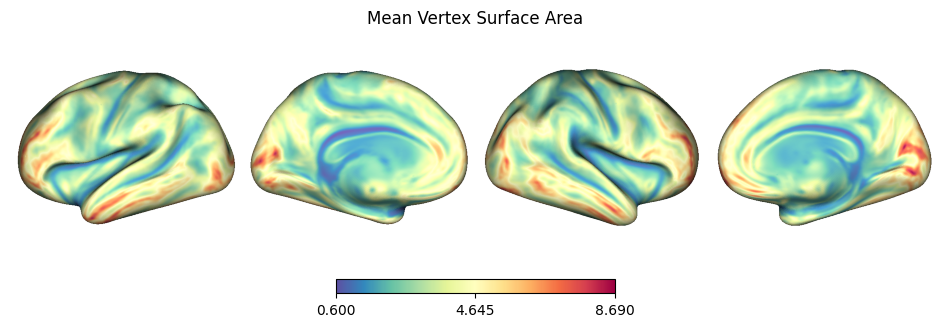

In [19]:
generic_area_file = "/data/data4/earlycort_7114/*/MNINonLinear/fsaverage_LR32k/*.{side}.midthickness.32k_fs_LR.area.func.gii"

all_L_area_files = glob.glob(generic_area_file.format(side="L"))
all_R_area_files = glob.glob(generic_area_file.format(side="R"))

L_SA_all_32k = np.expand_dims(np.array([nb.load(sf).darrays[0].data for sf in all_L_area_files]), -1)
R_SA_all_32k = np.expand_dims(np.array([nb.load(sf).darrays[0].data for sf in all_R_area_files]), -1)
SA_all_64k = np.concat([L_SA_all_32k, R_SA_all_32k], axis=1)
SA_all_cortex = SA_all_64k[:, ~medial_wall_mask_64k]
mean_SA_cortex = np.mean(SA_all_cortex, axis=0)

mean_L_SA = np.mean(L_SA_all_32k, axis=0)[:, 0]
mean_R_SA = np.mean(R_SA_all_32k, axis=0)[:, 0]

mean_SA_values = {"left": mean_L_SA, "right": mean_R_SA}
fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(mean_SA_values, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title("Mean Vertex Surface Area")

In [20]:
vni_s, vns_s = [], []
tr_label_s = []
for max_trs in tqdm([300, 1200, 2400, None]):
    generic_save_paths = []
    for subject in tqdm(subjects, leave=False):
        label_tag = pm.utils.create_path_tag(subject, sparsity, mask, exclude_subcortex, max_trs=max_trs)
        generic_save_paths.append(f"{results_dir}/{subject}/{label_tag}_{{file_ending}}")
    
    
    voxel_FC_save_paths = [path.format(file_ending=voxel_FC_file_ending) for path in generic_save_paths]
    parcel_save_paths = [path.format(file_ending=parcel_file_ending) for path in generic_save_paths]
    network_save_paths = [path.format(file_ending=network_file_ending) for path in generic_save_paths]
    
    for network_path in tqdm(network_save_paths):
        vni, vns = np.load(network_path)
        vns_s.append(vns)
        vni_s.append(vni)
        tr_label_s.append(max_trs)

vns_s = np.array(vns_s)
vni_s = np.array(vni_s).astype(int)
tr_label_s = np.array(tr_label_s)
tr_label_s = np.array([i if i else 3600 for i in tr_label_s])

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

In [21]:
vert_counts = np.array([(vns_s == net).mean(axis=1) for net in tqdm(network_labels, leave=False)]).T

  0%|          | 0/21 [00:00<?, ?it/s]

In [22]:
def percent_clip(arr, lower=None, upper=None):
    v = arr[~np.isnan(arr)]
    return np.clip(arr, np.percentile(v, lower or 0), np.percentile(v, upper or 100))

def vertex_plot(values, template_cifti, ax=None, pclip=(None, None), **kwargs):
    """ """
    values = percent_clip(values, *pclip)
    values = CAP_tools.utils.cifti_map(None, values, template_cifti)
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    return sfm.surface_plot(values, ax=ax, **kwargs)

In [23]:
subject_s_big = np.tile(subjects, (len(np.unique(tr_label_s))))

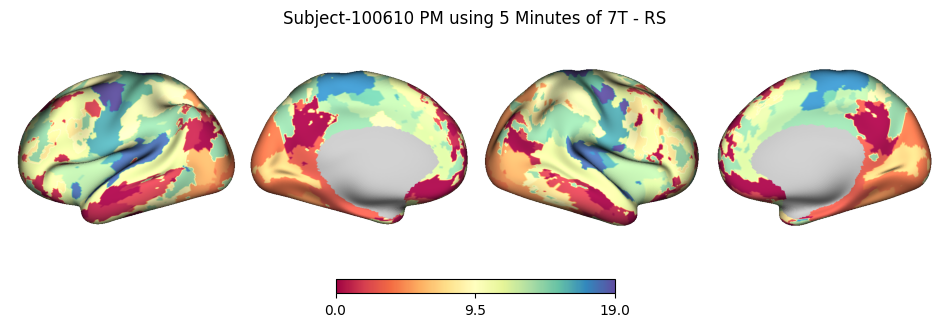

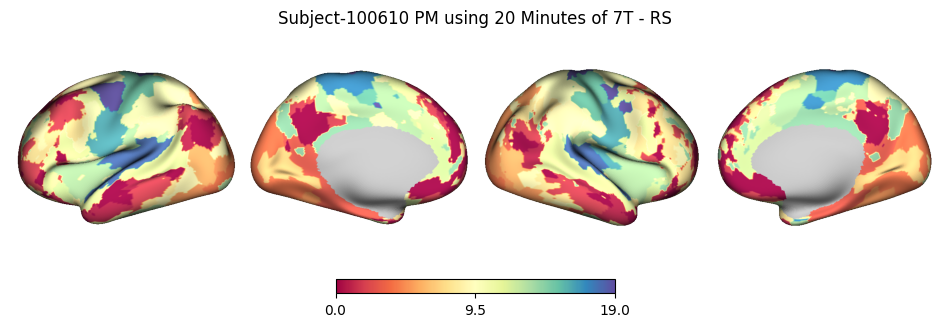

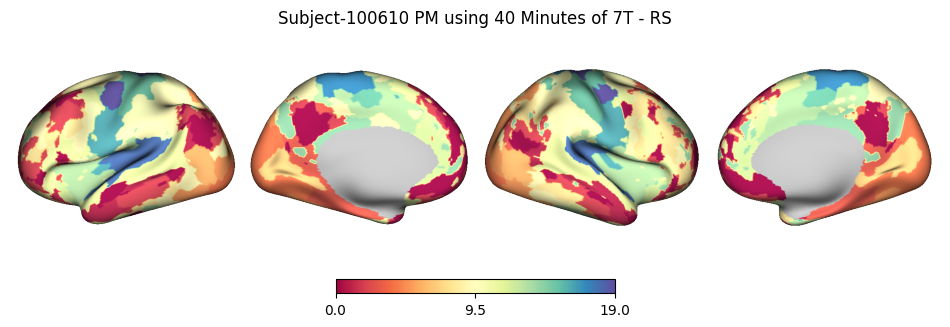

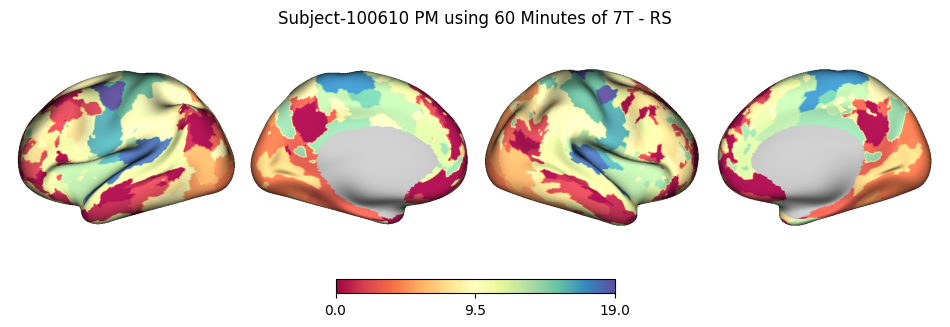

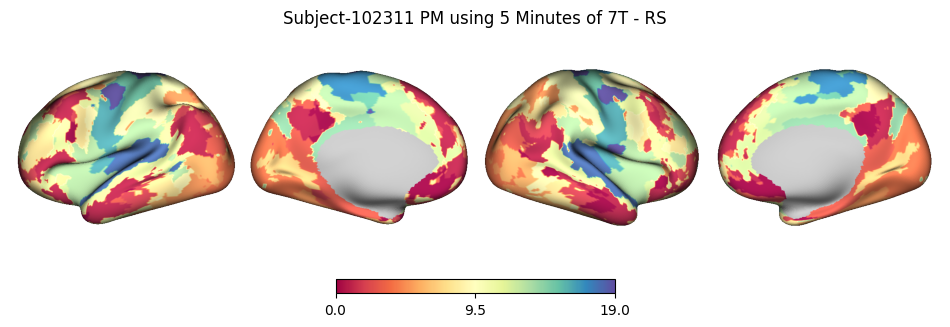

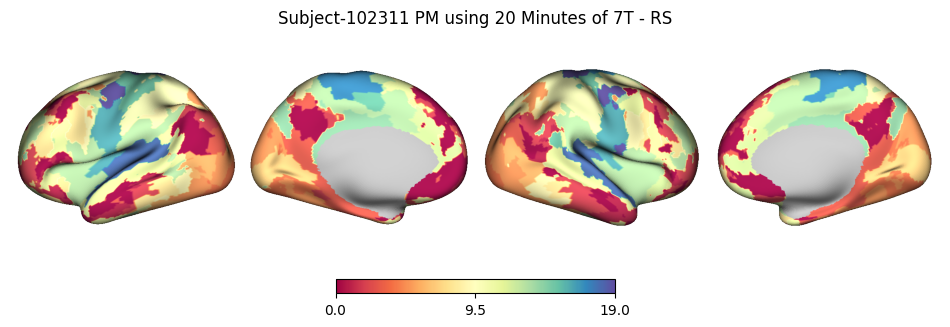

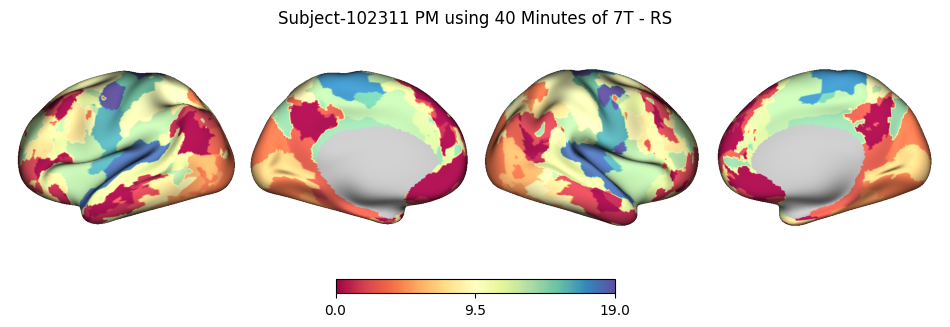

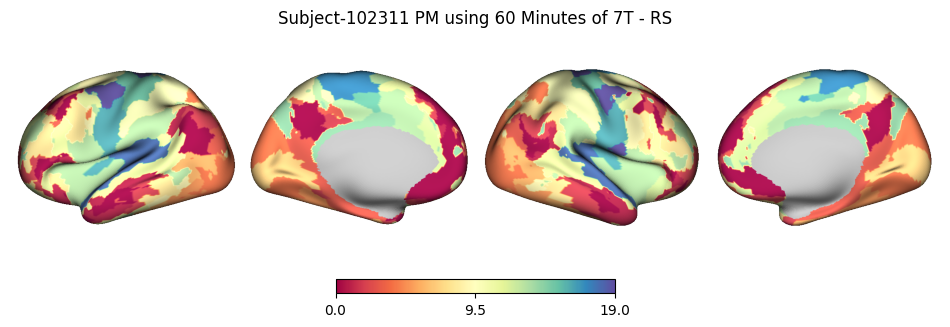

In [24]:
for subject in subjects[:2]:
    sid = subject_s_big == subject
    
    vni_subject_set = vni_s[sid]
    tr_subject_set = tr_label_s[sid]
    
    for vni_subject_tr, tr_subject in zip(vni_subject_set, tr_subject_set):
        ax, _ = vertex_plot(vni_subject_tr, example_cifti, cmap=plt.cm.Spectral)
        ax.set_title(f"Subject-{subject} PM using {tr_subject/60:0.0f} Minutes of 7T - RS")

In [29]:
compare_table = np.arange(np.max(vni_s) + 2).reshape(1, 1, -1)
ni_index_set = np.expand_dims(vni_s, 2) == compare_table
sizes = mean_SA_cortex * ni_index_set
size_frac = sizes / sizes.sum(axis=(1, 2), keepdims=True)
network_sizes = size_frac.sum(axis=1)

In [30]:
EC_vert_size_csv = "/data/data7/network_control/projects/precision_mapping/notebooks/scratch/EC_vert_count_data.csv"
EC_df = pd.read_csv(EC_vert_size_csv)
szp_index = EC_df["subject"].str.contains("_08_").values
EC_df["TR"] = np.array(["HC", "SzP"])[szp_index * 1]

# EC_sizes_csv = "/data/data7/network_control/projects/voxel_analysis/notebooks/scratch/EC_sizes_data.csv"
# EC_df = pd.read_csv(EC_sizes_csv)
# szp_index = EC_df["subject"].str.contains("_08_").values
# EC_df["TR"] = np.array(["HC", "SzP"])[szp_index * 1]

In [31]:
df = pd.DataFrame(vert_counts, columns=network_labels)
# df = pd.DataFrame(network_sizes, columns=network_labels)
df["subject"] = np.tile(subjects, (len(np.unique(tr_label_s))))
df["TR"] = tr_label_s

# df = pd.concat([df, EC_df])
mdf = pd.melt(df, id_vars=["subject", "TR"], var_name="network", value_name="n_vertices")

<Axes: xlabel='n_vertices', ylabel='network'>

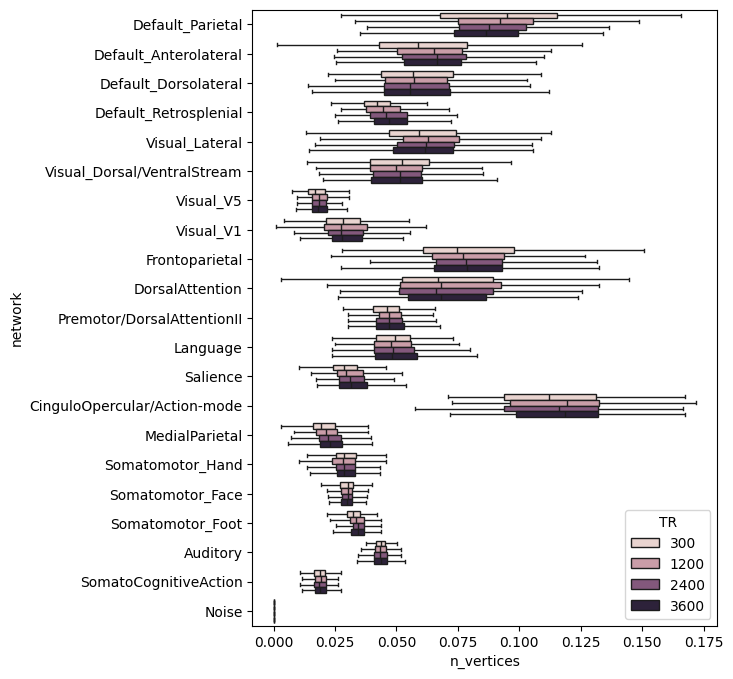

In [32]:
fig, ax = plt.subplots(figsize=(6, 8))
sns.boxplot(data=mdf, y="network", x="n_vertices", hue="TR", showfliers=False, ax=ax)
# sns.boxplot(data=mdf, y="network", x="n_vertices", hue="TR", showfliers=False, ax=ax)

In [33]:
hcp_1200 = df.query("TR == 1200")
szp_df = df.query("TR == 'SzP'")
hc_df = df.query("TR == 'HC'")

hcp_df = df.loc[df["TR"].apply(lambda s: isinstance(s, int))]

In [34]:
t_s, p_s = scipy.stats.ttest_ind(hcp_1200[network_labels], hc_df[network_labels])

for n, t, p in zip(network_labels, t_s, p_s):
    if p < 0.05:
        print(f"{n}:: {t:0.2f} {p:0.5f}")

/var/folders/p0/zng86kys7t3578bm_dw7qjym00014h/T/ipykernel_55979/55583869.py:1: SmallSampleWarning: All axis-slices of one or more sample arguments are too small; all elements of returned arrays will be NaN. See documentation for sample size requirements.
  t_s, p_s = scipy.stats.ttest_ind(hcp_1200[network_labels], hc_df[network_labels])


In [35]:
mtr_df = pd.melt(df[network_labels].groupby(df["TR"]).std().reset_index(), id_vars=["TR"], var_name="network", value_name="std")

In [36]:
size_corrs = []
lang_size_frac_diff_s = []
lang_sizes_s = []
for subject, subj_df in hcp_df.groupby("subject"):
    z = subj_df.sort_values("TR").drop("subject", axis=1).set_index("TR").T.corr()[3600]
    trs = z.index.values
    size_corrs.append(z.values)
    
    lang_sizes = subj_df.sort_values("TR").set_index("TR")["Language"]
    lang_sizes_s.append(lang_sizes)
    lang_size_frac_diff_s.append((lang_sizes.values[-1] - lang_sizes.values) / lang_sizes.values[-1])

size_corrs = np.array(size_corrs) ** 2
trs = trs.astype(int)
lang_size_frac_diff_s = np.array(lang_size_frac_diff_s)

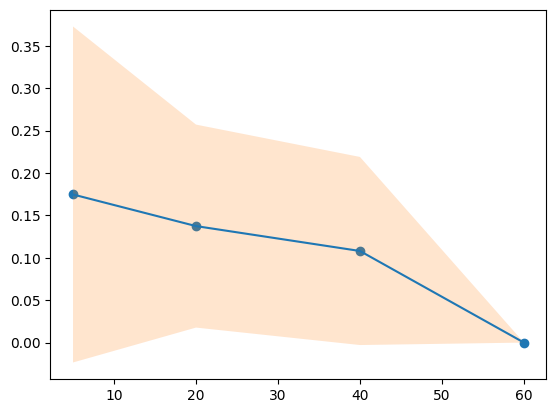

In [39]:
values = lang_size_frac_diff_s

m = np.mean(np.abs(values), axis=0)
s = np.std(np.abs(values), axis=0)
times = trs / 60

plt.plot(times, m)
plt.scatter(times, m)
plt.fill_between(times, m - s, m + s, alpha=0.2)

<Axes: ylabel='Density'>

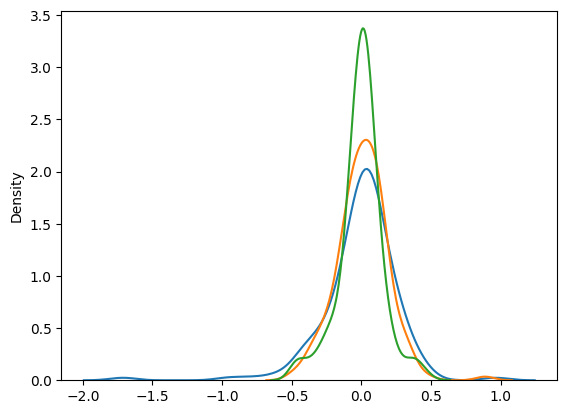

In [40]:
sns.kdeplot(lang_size_frac_diff_s[:, 0].ravel())
sns.kdeplot(lang_size_frac_diff_s[:, 1].ravel())
sns.kdeplot(lang_size_frac_diff_s[:, 2].ravel())

[Text(0.5, 0, 'Resting State Duration (Minutes)'),
 Text(0, 0.5, 'Size Correlation (R^2)')]

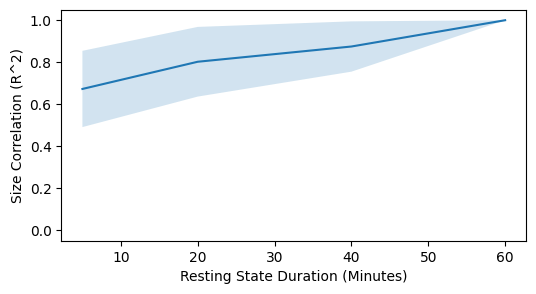

In [41]:
t = trs / 60
m, std = np.mean(size_corrs, axis=0),  np.std(size_corrs, axis=0)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(t, m)
ax.fill_between(t, m - std, m + std, alpha=0.2)
ax.set_ylim(-0.05, 1.05)
ax.set(xlabel="Resting State Duration (Minutes)", ylabel="Size Correlation (R^2)")

<Axes: xlabel='std', ylabel='network'>

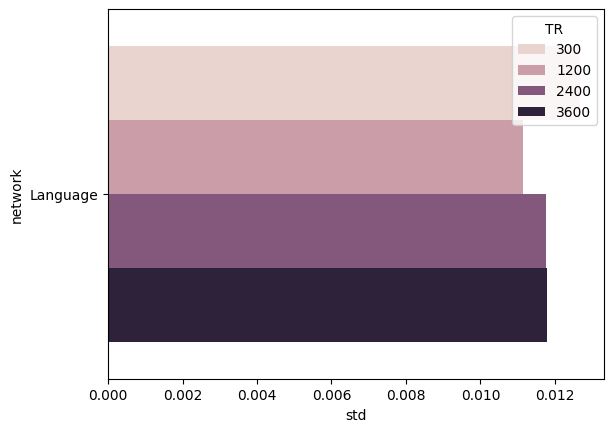

In [42]:
sns.barplot(data=mtr_df.query("network == 'Language'"), y="network", hue="TR", x="std")

# Network Size Stability
# TODOS:
- [] Plot individual parcellation over various TR step sizes
- [] Plot network assignment DICE overlap score over TR step sizes
- [] Plot network size over TR step sizes

# Associations with Pathology?

In [43]:
hcp_behav_df_path = "/Users/cole/Downloads/RESTRICTED_HCP_behavioral_data.csv"

In [44]:
hcp_behav_df = pd.read_csv(hcp_behav_df_path)
hcp_behav_df.columns = [col.lower() for col in hcp_behav_df.columns]
hcp_behav_df["subject"] = hcp_behav_df["subject"].astype(str)

In [45]:
hcp_mdf = pd.melt(hcp_df, id_vars=["subject", "TR"], var_name="network", value_name="n_vertices")

In [71]:
hcp_sb_df = hcp_mdf.merge(hcp_behav_df, on=["subject"], how="left")
hcp_sbr_df = hcp_sb_df.query("TR == 3600").copy()

hcp_sbr_df["famhist_dep"] = hcp_sbr_df["famhist_fath_dep"] + hcp_sbr_df["famhist_moth_dep"]
hcp_sbr_df["famhist_scz"] = hcp_sbr_df["famhist_fath_scz"] + hcp_sbr_df["famhist_moth_scz"]

hcp_sbr_df["famhist_bp"] = hcp_sbr_df["famhist_fath_bp"] + hcp_sbr_df["famhist_moth_bp"]
hcp_sbr_df["famhist_alz"] = hcp_sbr_df["famhist_fath_alz"] + hcp_sbr_df["famhist_moth_alz"]
hcp_sbr_df["famhist_anx"] = hcp_sbr_df["famhist_fath_anx"] + hcp_sbr_df["famhist_moth_anx"]
hcp_sbr_df["famhist_drgalc"] = hcp_sbr_df["famhist_fath_drgalc"] + hcp_sbr_df["famhist_moth_drgalc"]

hcp_sbr_df["suspect_dep"] = hcp_sbr_df["ssaga_depressive_sx"] > 5
hcp_sbr_df["suspect_dep"] = hcp_sbr_df["dsm_depr_t"] > 70

hcp_sbr_df["suspect_anx"] = hcp_sbr_df["dsm_anxi_t"] > 65
hcp_sbr_df["suspect_adhd"] = hcp_sbr_df["dsm_adh_t"] > 65


hcp_sbr_df["hx_dep"] = hcp_sbr_df["ssaga_depressive_ep"] == 5

hcp_sbr_df["suspect_aud"] = hcp_sbr_df["total_drinks_7days"] > 14
hcp_sbr_df["suspect_aud"] = hcp_sbr_df["avg_weekday_drinks_7days"] > 2

hcp_sbr_df["twin"] = hcp_sbr_df["zygositygt"] == "MZ"

hcp_sbr_df

,subject,TR,network,n_vertices,age_in_yrs,hasgt,zygositysr,zygositygt,family_id,mother_id,...,famhist_bp,famhist_alz,famhist_anx,famhist_drgalc,suspect_dep,suspect_anx,suspect_adhd,hx_dep,suspect_aud,twin
531,100610,3600,Default_Parietal,0.093264,27,True,NotMZ,DZ,52813_82634,52813,...,0.0,0.0,0.0,0.0,False,False,False,False,False,False
532,102311,3600,Default_Parietal,0.088669,26,True,MZ,MZ,51679_81543,51679,...,0.0,0.0,0.0,0.0,False,False,False,False,False,True
533,102816,3600,Default_Parietal,0.087659,30,True,MZ,MZ,51418_81283,51418,...,0.0,0.0,0.0,0.0,False,False,False,False,False,True
534,104416,3600,Default_Parietal,0.102185,31,True,MZ,MZ,54643_84465,54643,...,0.0,0.0,0.0,0.0,False,False,False,False,False,True
535,105923,3600,Default_Parietal,0.133896,33,True,MZ,,52925_82747,52925,...,0.0,0.0,0.0,0.0,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14863,951457,3600,Noise,0.000000,33,True,MZ,MZ,51519_81383,51519,...,0.0,0.0,0.0,0.0,False,False,False,False,False,True
14864,958976,3600,Noise,0.000000,29,True,NotMZ,DZ,52242_82105,52242,...,0.0,0.0,0.0,1.0,False,False,True,False,False,False
14865,966975,3600,Noise,0.000000,23,True,NotMZ,DZ,56023_85844,56023,...,0.0,0.0,0.0,0.0,False,False,False,False,False,False
14866,971160,3600,Noise,0.000000,27,True,MZ,MZ,52796_82617,52796,...,0.0,0.0,0.0,0.0,False,False,False,True,True,True


In [147]:
clin_vars = ['age_in_yrs',
 'handedness',
 'ssaga_employ',
 'ssaga_income',
 'ssaga_educ',
 'ssaga_inschool',
 'ssaga_rlshp',
 'ssaga_moborn',
 'height',
 'weight',
 'bmi',
 'ssaga_bmicat',
 'ssaga_bmicatheaviest',
 'hematocrit_1',
 'hematocrit_2',
 'bpsystolic',
 'bpdiastolic',
 'thyroidhormone',
 'hba1c',
 'famhist_moth_dep',
 'famhist_fath_dep',
 'famhist_moth_bp',
 'famhist_fath_bp',
 'famhist_moth_anx',
 'famhist_fath_anx',
 'famhist_moth_drgalc',
 'famhist_fath_drgalc',
 'asr_anxd_raw',
 'asr_anxd_pct',
 'asr_witd_raw',
 'asr_witd_t',
 'asr_soma_raw',
 'asr_soma_t',
 'asr_thot_raw',
 'asr_thot_t',
 'asr_attn_raw',
 'asr_attn_t',
 'asr_aggr_raw',
 'asr_aggr_t',
 'asr_rule_raw',
 'asr_rule_t',
 'asr_intr_raw',
 'asr_intr_t',
 'asr_oth_raw',
 'asr_crit_raw',
 'asr_intn_raw',
 'asr_intn_t',
 'asr_extn_raw',
 'asr_extn_t',
 'asr_tao_sum',
 'asr_totp_raw',
 'asr_totp_t',
 'dsm_depr_raw',
 'dsm_depr_t',
 'dsm_anxi_raw',
 'dsm_anxi_t',
 'dsm_somp_raw',
 'dsm_somp_t',
 'dsm_avoid_raw',
 'dsm_avoid_t',
 'dsm_adh_raw',
 'dsm_adh_t',
 'dsm_inat_raw',
 'dsm_hype_raw',
 'dsm_antis_raw',
 'dsm_antis_t',
 'ssaga_childhoodconduct',
 'ssaga_panicdisorder',
 'ssaga_agoraphobia',
 'ssaga_depressive_ep',
 'ssaga_depressive_sx',
 'total_drinks_7days',
 'num_days_drank_7days',
 'avg_weekday_drinks_7days',
 'avg_weekend_drinks_7days',
 'ssaga_alc_d4_dp_sx',
 'ssaga_alc_d4_ab_dx',
 'ssaga_alc_d4_ab_sx',
 'ssaga_alc_d4_dp_dx',
 'ssaga_alc_12_drinks_per_day',
 'ssaga_alc_12_frq',
 'ssaga_alc_12_frq_5plus',
 'ssaga_alc_12_frq_drk',
 'ssaga_alc_12_max_drinks',
 'ssaga_alc_age_1st_use',
 'ssaga_alc_hvy_drinks_per_day',
 'ssaga_alc_hvy_frq',
 'ssaga_alc_hvy_frq_5plus',
 'ssaga_alc_hvy_frq_drk',
 'ssaga_alc_hvy_max_drinks',
 'total_any_tobacco_7days',
 'times_used_any_tobacco_today',
 'num_days_used_any_tobacco_7days',
 'avg_weekday_any_tobacco_7days',
 'avg_weekend_any_tobacco_7days',
 'ssaga_ftnd_score',
 'ssaga_hsi_score',
 'ssaga_tb_age_1st_cig',
 'ssaga_tb_dsm_difficulty_quitting',
 'ssaga_tb_dsm_tolerance',
 'ssaga_tb_dsm_withdrawal',
 'ssaga_tb_hvy_cpd',
 'ssaga_tb_max_cigs',
 'ssaga_tb_reg_cpd',
 'ssaga_tb_smoking_history',
 'ssaga_tb_still_smoking',
 'ssaga_tb_yrs_since_quit',
 'ssaga_tb_yrs_smoked',
 'ssaga_times_used_illicits',
 'ssaga_times_used_cocaine',
 'ssaga_times_used_hallucinogens',
 'ssaga_times_used_opiates',
 'ssaga_times_used_sedatives',
 'ssaga_times_used_stimulants',
 'ssaga_mj_use',
 'ssaga_mj_ab_dep',
 'ssaga_mj_age_1st_use',
 'ssaga_mj_times_used',
]

In [160]:
rs, ps = [], []
for var in clin_vars:
    full_cdf = hcp_sbr_df.pivot(index=['subject', var], columns="network", values='n_vertices').reset_index()
    full_cdf = full_cdf.dropna()
    r_i, p_i = scipy.stats.pearsonr(full_cdf[var].values.reshape(-1, 1), full_cdf[network_labels[:-1]], axis=0)
    rs.append(r_i)
    ps.append(p_i)

rs = np.hstack(rs)
ps = np.hstack(ps)
qs = scipy.stats.false_discovery_control(ps)

print((qs < 0.05).sum())

0


<Axes: xlabel='n_vertices', ylabel='network'>

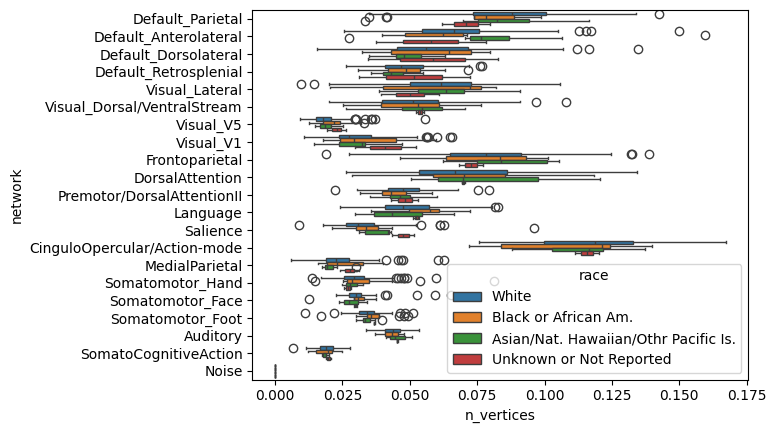

In [133]:
sns.boxplot(data=hcp_sbr_df, y="network", x="n_vertices", hue="race")

In [74]:
hcp_sbr_df["path"] = hcp_sbr_df["famhist_drgalc"] > 0
full_cdf = hcp_sbr_df.pivot(index=['subject', "path"], columns="network", values='n_vertices').reset_index()
full_cdf = full_cdf.dropna()

path_df = full_cdf.loc[full_cdf["path"]]
hc_df = full_cdf.loc[~full_cdf["path"]]

print("N pathology:", len(path_df))
print("N healthy:", len(hc_df))

t_s, p_s = scipy.stats.ttest_ind(path_df[network_labels[:-1]], hc_df[network_labels[:-1]])

q_s = scipy.stats.false_discovery_control(p_s)

sig_index = p_s < 0.05
print(network_labels[:-1][sig_index])
print(p_s[sig_index])

path_m_sizes = path_df[network_labels[:-1]].mean()
hc_m_sizes = hc_df[network_labels[:-1]].mean()
size_ratio = path_m_sizes / hc_m_sizes

print(size_ratio[sig_index])
for i, r, p, q in zip(size_ratio.index, size_ratio, p_s, q_s):
    print(f"{i} :: {r:.2f}, {p:0.3f}, {q:0.3f}")

N pathology: 30
N healthy: 147
[]
[]
Series([], dtype: float64)
Default_Parietal :: 0.97, 0.574, 0.882
Default_Anterolateral :: 1.11, 0.098, 0.656
Default_Dorsolateral :: 0.95, 0.489, 0.868
Default_Retrosplenial :: 1.03, 0.521, 0.868
Visual_Lateral :: 0.97, 0.652, 0.931
Visual_Dorsal/VentralStream :: 0.96, 0.511, 0.868
Visual_V5 :: 1.05, 0.425, 0.868
Visual_V1 :: 0.98, 0.768, 0.958
Frontoparietal :: 0.95, 0.346, 0.868
DorsalAttention :: 1.12, 0.073, 0.656
Premotor/DorsalAttentionII :: 1.00, 0.948, 0.958
Language :: 0.94, 0.236, 0.868
Salience :: 1.07, 0.266, 0.868
CinguloOpercular/Action-mode :: 0.95, 0.193, 0.868
MedialParietal :: 1.13, 0.062, 0.656
Somatomotor_Hand :: 1.00, 0.958, 0.958
Somatomotor_Face :: 1.00, 0.898, 0.958
Somatomotor_Foot :: 0.98, 0.517, 0.868
Auditory :: 1.00, 0.843, 0.958
SomatoCognitiveAction :: 0.99, 0.820, 0.958


# Twin Analysis

In [ ]:
twin_pairs = []

In [177]:
twin_df = [g for g in hcp_sbr_df.groupby("mother_id")]

In [257]:
subject_pair_list = [(s1, s2) for i, s1 in enumerate(subjects) for s2 in subjects[:i] if s1 != s2]
subject_pair_dfs = [hcp_sbr_df[hcp_sbr_df["subject"].isin(pair)] for pair in subject_pair_list]
twin_labels = ["Unrelated" if len(df["mother_id"].unique()) == 2 else df["zygositysr"].iloc[0] for df in subject_pair_dfs]
# twin_labels = ["unrelated" if len(df["mother_id"].unique()) == 2 else "twin" for df in subject_pair_dfs]

In [259]:
pair = subject_pair_list[0]
df = subject_pair_dfs[0]

In [260]:
(hcp_sbr_df["zygositysr"] == "NotMZ").sum()

np.int64(1764)

In [261]:
hcp_sbr_df["zygositysr"].unique()

array(['NotMZ', 'MZ', 'NotTwin'], dtype=object)

In [268]:
diff_s = []
for df, pair in zip(tqdm(subject_pair_dfs), subject_pair_list):
    df = df.sort_values("network")
    sizes_1 = df.loc[df["subject"] == pair[0]]["n_vertices"].values
    sizes_2 = df.loc[df["subject"] == pair[1]]["n_vertices"].values

    # diff_s.append(np.abs(sizes_1 - sizes_2))
    diff_s.append(np.abs(sizes_1 - sizes_2) / np.abs(sizes_1 + sizes_2) / 2)
diff_s = np.array(diff_s)

  0%|          | 0/15576 [00:00<?, ?it/s]

/var/folders/p0/zng86kys7t3578bm_dw7qjym00014h/T/ipykernel_55979/684164691.py:8: RuntimeWarning: invalid value encountered in divide
  diff_s.append(np.abs(sizes_1 - sizes_2) / np.abs(sizes_1 + sizes_2) / 2)


In [274]:
pair_df = pd.DataFrame(diff_s, columns=network_labels)
pair_df["twin"] = twin_labels
pair_df["mean"] = pair_df[network_labels[:-1]].mean(axis=1)

In [294]:
pair_df.shape

(15576, 23)

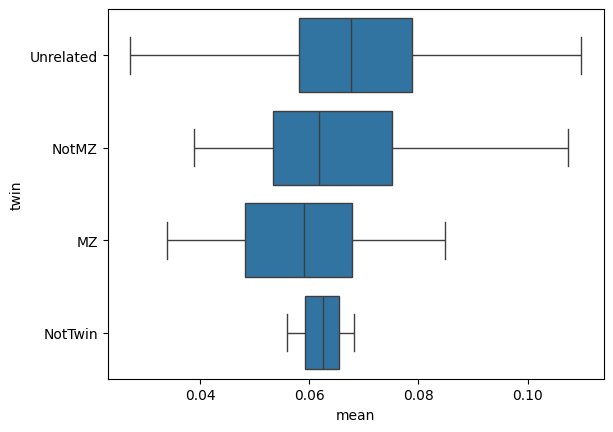

In [291]:
ax = sns.boxplot(data=pair_df, x="mean", y="twin", showfliers=False)

In [292]:
def ttest(var, index):
    """ """
    assert all(np.isin(index, [True, False]))
    if isinstance(var, pd.core.frame.DataFrame):
        return scipy.stats.ttest_1samp(var.loc[index], var.loc[~index])

    return scipy.stats.ttest_ind(var[index], var[~index])

In [293]:

ttest(pair_df["mean"], pair_df["twin"] == "Unrelated")

TtestResult(statistic=np.float64(4.528854640010722), pvalue=np.float64(5.974437554668628e-06), df=np.float64(15574.0))

# Intra Parcel Connectivity Analysis

In [126]:
ex_index = 0

In [327]:
network_path = network_save_paths[ex_index]
FC_path = voxel_FC_save_paths[ex_index]
partition_path = parcel_save_paths[ex_index]

template_cifti = template_cifti

In [446]:
def load_FC_cortex(FC_path, template_cifti):
    """ """
    sc = scipy.sparse.load_npz(FC_path)
    cortex_index = pm.na.get_cortex_data(np.arange(sc.shape[0]).reshape(1, -1), template_cifti)[0]
    return sc[cortex_index][:, cortex_index]

def load_partition_labels(partition_path, template_cifti):
    """ """
    partition = np.load(partition_path)
    vertex_labels = pm.na.get_partition_cortex(partition, template_cifti)
    vertex_labels[np.isnan(vertex_labels)] = np.nanmax(vertex_labels) + 1
    remapped_vertex_labels = np.unique(vertex_labels, return_inverse=True)[1]
    return remapped_vertex_labels

def load_network_labels(network_path):
    return np.load(network_save_path)[0].astype(int)

def safe_mean(arr, **kwargs):
    # if arr.ndim == 1 and len(arr) == 0:
    #     return np.nan
    return np.mean(arr, **kwargs)


def calculate_mean_ROI_fc(sc_cortex, vertex_labels, only_nonzero=True, partial_nonzero=True):
    """ """
    unl = np.sort(np.unique(vertex_labels))
    if only_nonzero:
        mean_parcel_fc = np.array([safe_mean(sc_cortex[vertex_labels == label].data) for label in unl])
        mean_intraparcel_fc = np.array([safe_mean(sc_cortex[vertex_labels == label][:, vertex_labels == label].data) for label in unl])
    elif partial_nonzero:
        parcel_fc_z = np.vstack([safe_mean(sc_cortex[vertex_labels == label], axis=0).reshape(-1) for label in unl])
        mean_parcel_fc = np.array([safe_mean(parcel_fc[parcel_fc > 0]) for parcel_fc in parcel_fc_z])
        mean_intraparcel_fc = np.array([safe_mean(parcel_fc[(parcel_fc > 0) & (vertex_labels == label)])
                                        for label, parcel_fc in zip(unl, parcel_fc_z)])
    else:
        parcel_fc = np.vstack([safe_mean(sc_cortex[vertex_labels == label], axis=0).reshape(-1) for label in unl])
        mean_parcel_fc = np.array([safe_mean(parcel_fc) for parcel_fc in parcel_fc])
        mean_intraparcel_fc = np.array([safe_mean(parcel_fc[:, vertex_labels == label]) for label, parcel_fc in zip(unl, parcel_fc)])

    return mean_parcel_fc, mean_intraparcel_fc

def percent_clip(arr, lower=None, upper=None):
    v = arr[~np.isnan(arr)]
    return np.clip(arr, np.percentile(v, lower or 0), np.percentile(v, upper or 100))

def vertex_plot(values, template_cifti, ax=None, pclip=(None, None), **kwargs):
    """ """
    values = percent_clip(values, *pclip)
    values = CAP_tools.utils.cifti_map(None, values, template_cifti)
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    return sfm.surface_plot(values, ax=ax, **kwargs)

In [447]:
sc_cortex = load_FC_cortex(FC_path, template_cifti)
pni = load_partition_labels(partition_path, template_cifti)
vni = load_network_labels(network_path)

In [463]:
mean_parcel_fc_nz, mean_intraparcel_fc_nz = calculate_mean_ROI_fc(sc_cortex, pni, only_nonzero=True)
mean_network_fc_nz, mean_intranetwork_fc_nz = calculate_mean_ROI_fc(sc_cortex, vni, only_nonzero=True)

/Users/cole/miniconda3/envs/nct/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/cole/miniconda3/envs/nct/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


(<Axes: >, <surfplot.plotting.Plot at 0x41ddcb910>)

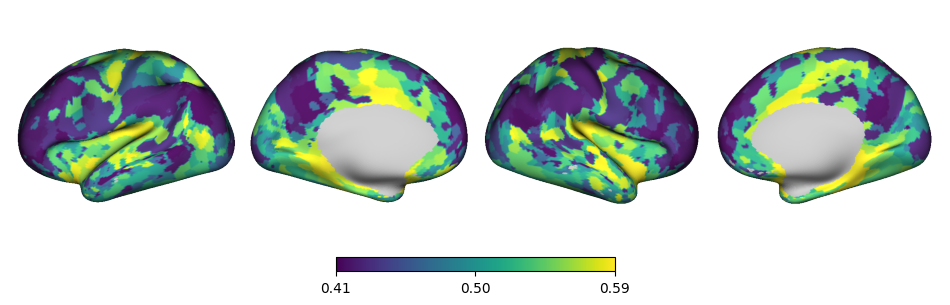

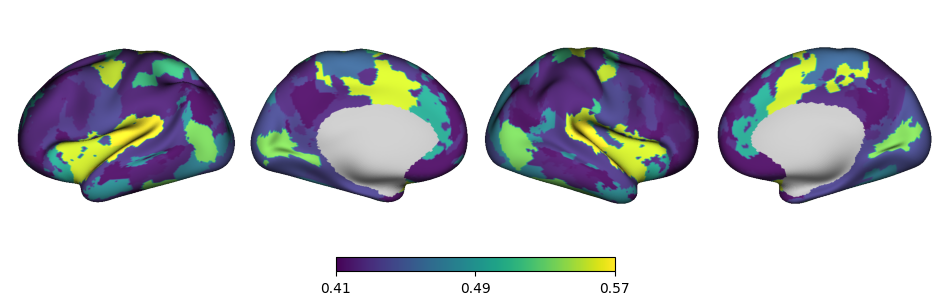

In [466]:
vertex_plot(mean_parcel_fc_nz[pni], template_cifti, cmap=plt.cm.viridis, pclip=(1, 95))
# vertex_plot(mean_intraparcel_fc_nz[pni], template_cifti, cmap=plt.cm.viridis, pclip=(1, 99))
vertex_plot(mean_network_fc_nz[vni], template_cifti, cmap=plt.cm.viridis, pclip=(1, 99))

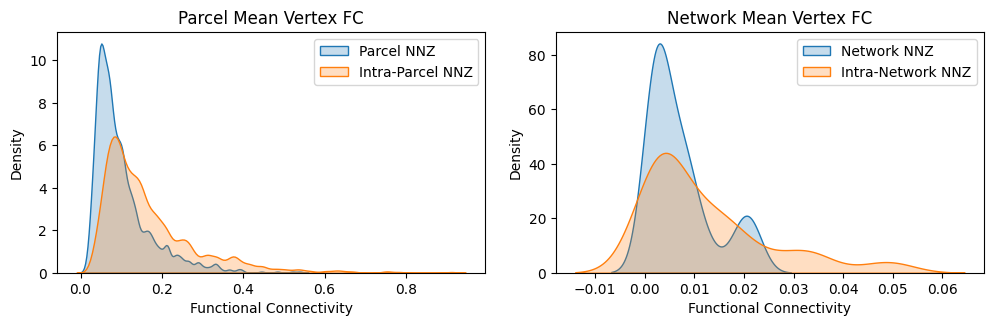

In [458]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
fig.tight_layout(w_pad=2)

for ax, label, (roi_means, intraroi_means) in zip(axes, ["Parcel", "Network"], [[mean_parcel_fc_nz, mean_intraparcel_fc_nz],
                                                   [mean_network_fc_nz, mean_intranetwork_fc_nz]]):

    bw = 0.1 if len(roi_means) > 500 else 0.4
    sns.kdeplot(roi_means, bw_method=bw, ax=ax, label=f"{label} NNZ", fill=True)
    sns.kdeplot(intraroi_means, bw_method=bw, ax=ax, label=f"Intra-{label} NNZ", fill=True)
    ax.set(title=f"{label} Mean Vertex FC", ylabel="Density", xlabel="Functional Connectivity")
    ax.legend()

[Text(0.5, 25.722222222222214, 'Intra Network Mean Vertex Functional Connectivity'),
 Text(619.9949494949494, 0.5, 'Network')]

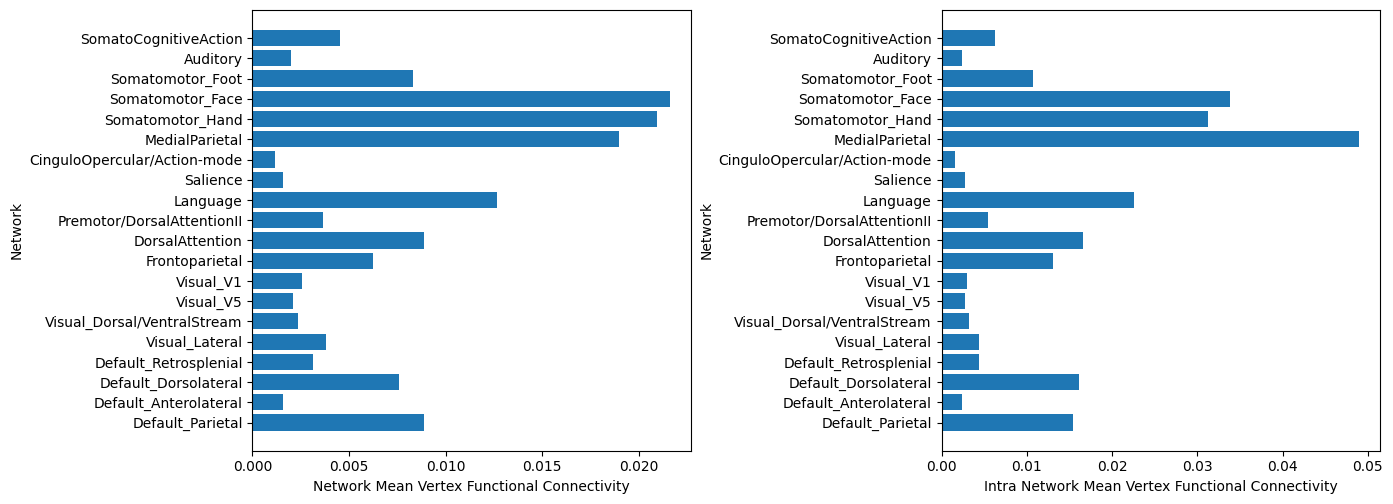

In [459]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.tight_layout(w_pad=15)
axes[0].barh(network_labels[:-1], mean_network_fc_nz)
axes[0].set(xlabel="Network Mean Vertex Functional Connectivity", ylabel="Network")

axes[1].barh(network_labels[:-1], mean_intranetwork_fc_nz)
axes[1].set(xlabel="Intra Network Mean Vertex Functional Connectivity", ylabel="Network")

<Axes: >

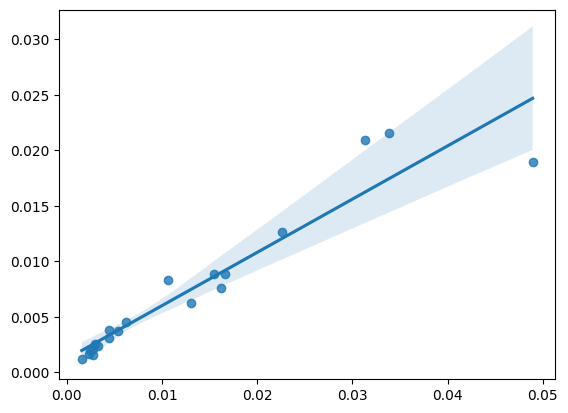

In [460]:
sns.regplot(x=mean_intranetwork_fc_nz, y=mean_network_fc_nz)

In [200]:
vni, vns = np.load(network_save_path)
vni = vni.astype("int")

sc = scipy.sparse.load_npz(voxel_FC_save_path)
cortex_index = pm.na.get_cortex_data(np.arange(sc.shape[0]).reshape(1, -1), template_cifti)[0]
sc_cortex = sc[cortex_index][:, cortex_index]

partition = np.load(partition_save_path)
vertex_labels = pm.na.get_partition_cortex(partition, template_cifti)
vertex_labels[np.isnan(vertex_labels)] = np.nanmax(vertex_labels) + 1
remapped_vertex_labels = np.unique(vertex_labels, return_inverse=True)[1]
pni = remapped_vertex_labels

cluster_labels = np.sort(np.unique(remapped_vertex_labels))
roi_index_set = remapped_vertex_labels.reshape(-1, 1) == cluster_labels

In [305]:
mean_parcel_fc_nz, mean_intraparcel_fc_nz = calculate_mean_ROI_fc(sc_cortex, remapped_vertex_labels, only_nonzero=True)
mean_network_fc_nz, mean_intranetwork_fc_nz = calculate_mean_ROI_fc(sc_cortex, vni, only_nonzero=True)

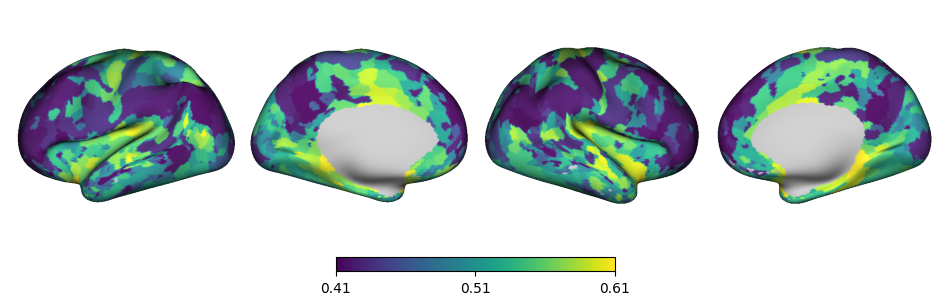

In [343]:
# z = mean_intraparcel_fcs[pni]
z = mean_intraparcel_fc_nz[pni]

# z = mean_parcel_fcs[pni]
z = mean_parcel_fc_nz[pni]

# z = mean_network_fc_s[vni]
# z = mean_network_fc_nz[vni]

# z = mean_intranetwork_fc_s[vni]
# z = mean_intranetwork_fc_nz[vni]

z = np.clip(z, np.percentile(z[~np.isnan(z)], 2), np.percentile(z[~np.isnan(z)], 99))

values = CAP_tools.utils.cifti_map(None, z, template_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(values, cmap=plt.cm.viridis, ax=ax)

In [171]:
template_cifti = nb.load(cached_dtseries_paths[ex_index])

# full_vertex_data = pm.utils.load_voxel_data(dtseries_paths[ex_index])
# print(full_vertex_data.shape)
# vertex_data = pm.na.get_cortex_data(full_vertex_data, template_cifti)
# vertex_data = None

partition = np.load(parcel_save_paths[ex_index])
vertex_labels = pm.na.get_partition_cortex(partition, template_cifti)

In [172]:
vertex_labels[np.isnan(vertex_labels)] = np.nanmax(vertex_labels) + 1
remapped_vertex_labels = np.unique(vertex_labels, return_inverse=True)[1]

cluster_labels = np.sort(np.unique(remapped_vertex_labels))
roi_index_set = remapped_vertex_labels.reshape(-1, 1) == cluster_labels

FC, spatial, network_labels = pm.na.load_priors()
sp_corr = pm.utils.np_corr(spatial.T, roi_index_set * 1)

# roi_mean_signals = np.array([vertex_data[:, ri].mean(axis=1) for ri in roi_index_set.T]).T
# roi_mean_FCs = pm.utils.np_corr(vertex_data, roi_mean_signals)
# fc_corr = pm.utils.np_corr(FC.T, roi_mean_FCs)
# sp_fc_corr = sp_corr * fc_corr

sp_fc_index = np.argmax(sp_corr, axis=0)
# sp_fc_index = np.argmax(sp_fc_corr, axis=0)

vn = sp_fc_index[remapped_vertex_labels]
pn = remapped_vertex_labels
# roi_mean_signals = np.array([vertex_data[:, ri].mean(axis=1) for ri in roi_index_set.T]).T
# roi_mean_FCs = utils.np_corr(vertex_data, roi_mean_signals)

In [173]:
pn.shape

(59412,)

In [174]:
sc = scipy.sparse.load_npz(voxel_FC_save_paths[ex_index])

cortex_index = pm.na.get_cortex_data(np.arange(sc.shape[0]).reshape(1, -1), template_cifti)[0]
sc_cortex = sc[cortex_index][:, cortex_index]

In [175]:
sc, roi_index_set.shape

(<Compressed Sparse Row sparse matrix of dtype 'float32'
 	with 8332312 stored elements and shape (91282, 91282)>,
 (59412, 1071))

In [176]:
parcel_fc_nz = [np.nanmean(sc_cortex[roi_index_set[:, i]].data) for i in range(roi_index_set.shape[1])]

/var/folders/p0/zng86kys7t3578bm_dw7qjym00014h/T/ipykernel_58350/3375776889.py:1: RuntimeWarning: Mean of empty slice
  parcel_fc_nz = [np.nanmean(sc_cortex[roi_index_set[:, i]].data) for i in range(roi_index_set.shape[1])]


In [177]:
parcel_fc_s = np.vstack([np.mean(sc_cortex[roi_index_set[:, i]], axis=0).reshape(-1) for i in range(roi_index_set.shape[1])])
mean_parcel_fcs = np.array([np.mean(parcel_fc[parcel_fc > 0]) for parcel_fc in parcel_fc_s])
mean_intraparcel_fcs = np.array([np.mean(parcel_fc[(parcel_fc > 0) & (pn == i)]) for i, parcel_fc in enumerate(parcel_fc_s)])

mean_intranetwork_parcel_fcs = np.array([np.mean(parcel_fc[(parcel_fc > 0) & (vn == sp_fc_index[i])]) for i, parcel_fc in enumerate(parcel_fc_s)])

/Users/cole/miniconda3/envs/nct/lib/python3.11/site-packages/numpy/matrixlib/defmatrix.py:448: RuntimeWarning: Mean of empty slice.
  return N.ndarray.mean(self, axis, dtype, out, keepdims=True)._collapse(axis)
/Users/cole/miniconda3/envs/nct/lib/python3.11/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [178]:
np.nanmean(mean_intraparcel_fcs), np.nanmean(mean_intranetwork_parcel_fcs), np.nanmean(mean_parcel_fcs), len(sp_fc_index)

(np.float32(0.16633612), np.float32(0.12497975), np.float32(0.10196546), 1071)

In [179]:
nnz_row = np.array(np.sum(sc_cortex > 0, axis=0))

vertex_fc_s = np.array(sc_cortex.sum(axis=0)) / (nnz_row + (nnz_row == 0))

In [180]:
z = mean_intranetwork_parcel_fcs[vn]
z = mean_intraparcel_fcs[pn]
# z = mean_parcel_fcs[pn]
z = np.clip(z, np.percentile(z[~np.isnan(z)], 2), np.percentile(z[~np.isnan(z)], 99))

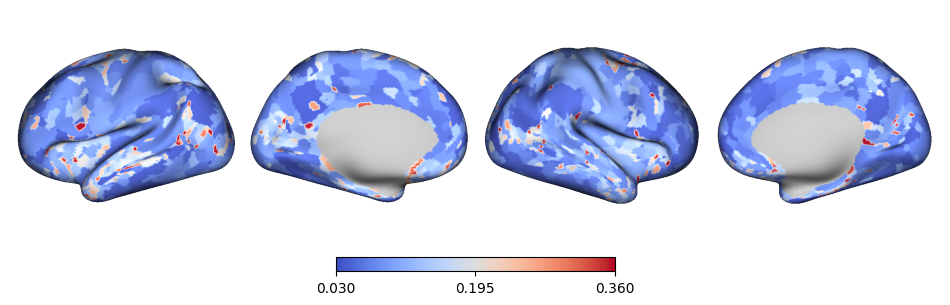

In [181]:
values = CAP_tools.utils.cifti_map(None, z, template_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(values, cmap=plt.cm.coolwarm, ax=ax)

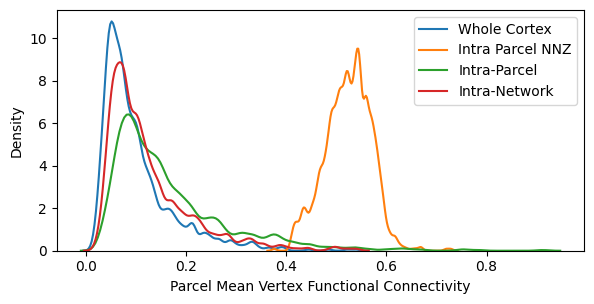

In [182]:
bw = 0.1
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
fig.tight_layout(w_pad=0)
sns.kdeplot(mean_parcel_fcs, bw_method=bw, ax=ax, label="Whole Cortex")
sns.kdeplot(parcel_fc_nz, bw_method=bw, ax=ax, label="Intra Parcel NNZ")
sns.kdeplot(mean_intraparcel_fcs, bw_method=bw, ax=ax, label="Intra-Parcel")
sns.kdeplot(mean_intranetwork_parcel_fcs, bw_method=bw, ax=ax, label="Intra-Network")
ax.set(xlabel="Parcel Mean Vertex Functional Connectivity", ylabel="Density")
ax.legend()

In [107]:
network_fc_s = np.array([np.mean(sc_cortex[vn == i], axis=0) for i in range(np.max(vn) + 1)]).squeeze()
mean_network_fc_s = np.array([np.mean(network_fc[network_fc > 0]) for network_fc in network_fc_s])

mean_intranetwork_fc_s = np.array([np.mean(network_fc[(network_fc > 0) & (vn == i)]) for i, network_fc in enumerate(network_fc_s)])

In [115]:
mean_network_fc_s.shape

(20,)

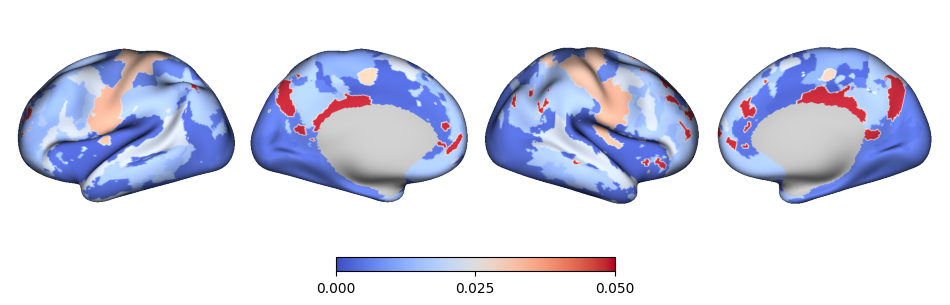

In [119]:
z = mean_network_fc_s[vn]
z = mean_intranetwork_fc_s[vn]

z = np.clip(z, np.percentile(z[~np.isnan(z)], 2), np.percentile(z[~np.isnan(z)], 99))
values = CAP_tools.utils.cifti_map(None, z, template_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(values, cmap=plt.cm.coolwarm, ax=ax)

[Text(0.5, 25.722222222222214, 'Intra Network Mean Vertex Functional Connectivity'),
 Text(619.9949494949494, 0.5, 'Network')]

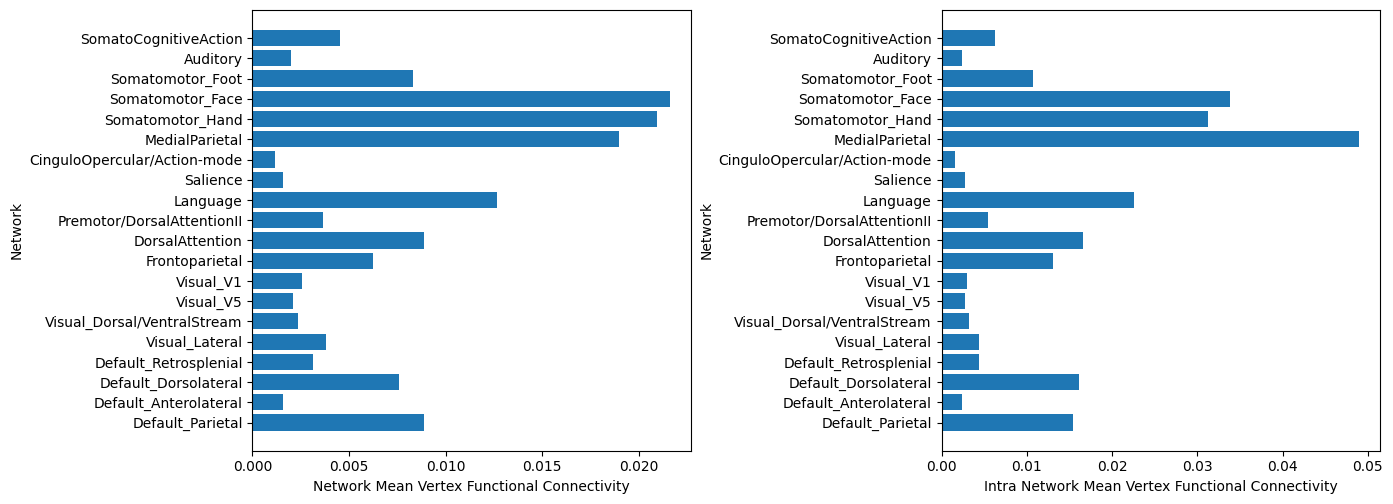

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.tight_layout(w_pad=15)
axes[0].barh(network_labels[:-1], mean_network_fc_s)
axes[0].set(xlabel="Network Mean Vertex Functional Connectivity", ylabel="Network")

axes[1].barh(network_labels[:-1], mean_intranetwork_fc_s)
axes[1].set(xlabel="Intra Network Mean Vertex Functional Connectivity", ylabel="Network")